# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 7     |  |
| :-------------|:-------------|
| Isha Schneiders| 6384838|
| Jinzhou Mo| 6126537 |

In [1]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

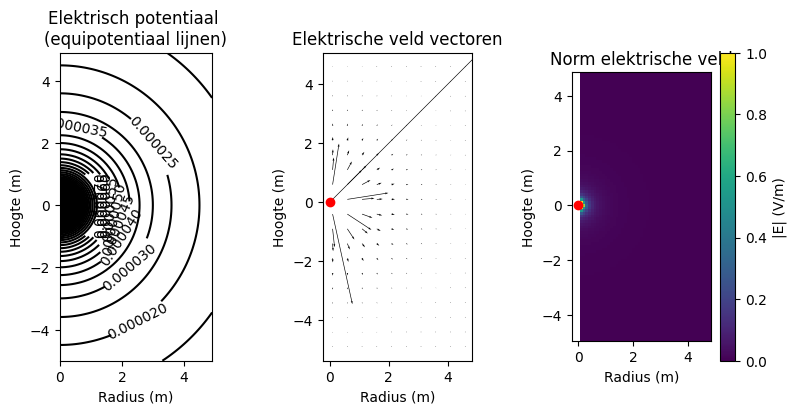

In [2]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

De index die correspondeert met z=0m is 50
of zo kan ook, index= 50



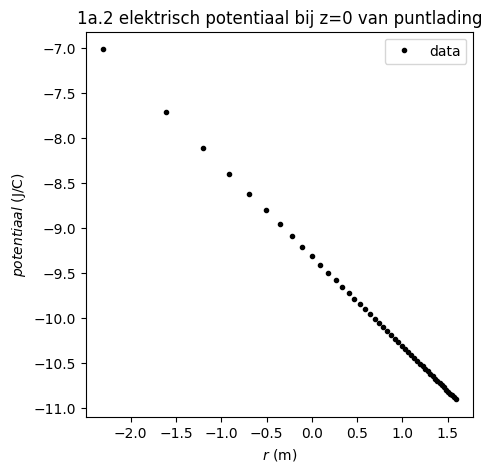

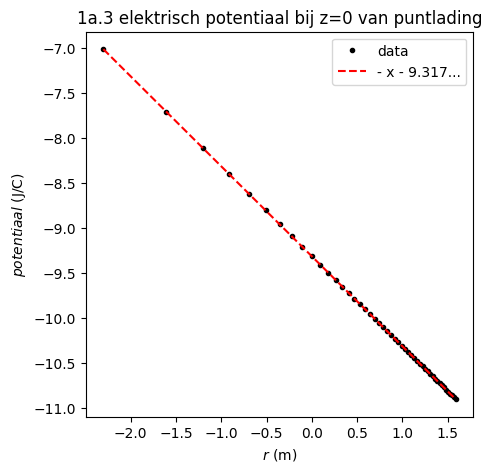

Het exponent is bepaald op -1.0000000000000000 ± 1e-16, dit komt overeen met de -1 die je volgens de theorie verwacht


In [3]:
from scipy.optimize import curve_fit
#------!!!deze cel runt niet goed als je hem apart runt maar met run all wel, ik heb echt geen flauw idee waarom dit gebeurt \
#maar wat ik zie is dat de potentiaal V een andere array wordt als je deze cel los runt!!!---------  
#om dit optelossen heb ik nu wat oude code hier naartoe verplaats:
charge_one_point = 1e-14  # lading van 1 punt (C)
r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)


###-------1-------###
print("De index die correspondeert met z=0m is",np.argmin(np.abs(z))) #uit de print command blijkt dat 0 niet echt in de z-array zit, maar er zit wel een hele kleine waarde in(orde 10^-14) vergeleken met de andere en dit is dus de oorsprong, np.abs omdat er ook negatieve waarden in de z-array zit
print("of zo kan ook, index=",find_idx_nearest(0,z))
print()



###-------2-------###
#uit de functies in functions_electrostatics volgt dat V[i,j]=V(z[i],r[j])

#log van de data bij z=0 (daar zit de puntlading):
log_r=np.log(r[r!=0]) #r[r!=0] geeft alle waarden waar r ongelijk is aan nul want log (0) kan ni
log_pot=np.log(V[50,V[50,]!=0]) #z=0 is bij idx 50, V[50,]!=0 geeft de indexen waar V[50,] ongelijk is aan nul want log(0) kan ni

#plotten
plt.figure(figsize=(5,5))
plt.title("1a.2 elektrisch potentiaal bij z=0 van puntlading")
plt.plot(log_r,log_pot,"k.",label="data")
plt.xlabel("$r$ (m)")
plt.ylabel("$potentiaal$ (J/C)")
plt.legend()
plt.show()



###-------3------###
#fitfunctie:
def f(x,a,b):
    '''verband in de data is duidelijk een rechte lijn dus daarom een lineaire functie'''
    return a*x+b

#curvefit:
val,cov=curve_fit(f,log_r,log_pot)
a,b=val #waarden van a en b
u_a,u_b=np.sqrt(np.diag(cov)) #onzekerheden in a en b

#plotten
x_plot=np.linspace(min(log_r),max(log_r),100)#array om fit mee te plotten
plt.figure(figsize=(5,5))
plt.title("1a.3 elektrisch potentiaal bij z=0 van puntlading")
plt.plot(log_r,log_pot,"k.",label="data")#data
plt.plot(x_plot,f(x_plot,*val),"r--",label=r"- x - 9.317...")#fit
plt.xlabel("$r$ (m)")
plt.ylabel("$potentiaal$ (J/C)")
plt.legend()
plt.show()



###------4------###
print("Het exponent is bepaald op %.16f \u00b1 %.0e, dit komt overeen met de -1 die je volgens de theorie verwacht"%(a,u_a))

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

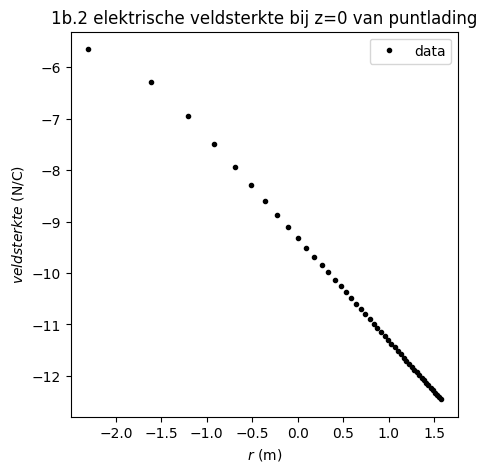

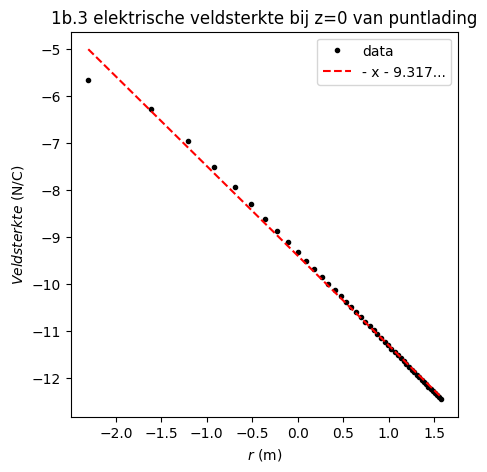

Het exponent is bepaald op -1.91 ± 0.02

Het exponent zonder (afwijkend) punt is bepaald op -1.981 ± 0.004, dit lijkt al meer op de -2 die je volgens de theorie zou verwachten


In [4]:
#------!!!deze cel runt niet goed als je hem apart runt maar met run all wel, ik heb echt geen flauw idee waarom dit gebeurt \
#maar wat ik zie is dat de potentiaal V een andere array wordt als je deze cel los runt!!!---------  
#om dit optelossen heb ik nu wat oude code hier naartoe verplaats:
charge_one_point = 1e-14  # lading van 1 punt (C)
r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)
Er, Ez, normE = compute_E_pt_charge(V, B, grid_step) 
r_for_E = r[1:-1]  
z_for_E = z[1:-1]  




###-------2------### Plot de log van het elerktrisch veld tegen de log van de straal.
#uit de functies in functions_electrostatics volgt dat normE[i,j]=normE(z[i],r[j])

#log van de data bij z=0 (daar zit de puntlading):
log_r=np.log(r_for_E[:]) 
log_E=np.log(normE[50,:]) #z=0 is bij idx 50

#plotten
plt.figure(figsize=(5,5))
plt.title("1b.2 elektrische veldsterkte bij z=0 van puntlading")
plt.plot(log_r,log_E,"k.",label="data")
plt.xlabel("$r$ (m)")
plt.ylabel("$veld sterkte$ (N/C)")
plt.legend()   
plt.show()



###-------3------###
#fitfunctie:
def f(x,a,b):
    '''verband in de data is duidelijk een rechte lijn dus daarom een lineaire functie'''
    return a*x+b

#curvefit:
val,cov=curve_fit(f,log_r,log_E)
a,b=val #waarden van a en b
u_a,u_b=np.sqrt(np.diag(cov)) #onzekerheden in a en b

#plotten
x_plot=np.linspace(min(log_r),max(log_r),100)#array om fit mee te plotten
plt.figure(figsize=(5,5))
plt.title("1b.3 elektrische veldsterkte bij z=0 van puntlading")
plt.plot(log_r,log_E,"k.",label="data")#data
plt.plot(x_plot,f(x_plot,*val),"r--",label=r"- x - 9.317...")#fit
plt.xlabel("$r$ (m)")
plt.ylabel("$Veldsterkte$ (N/C)")
plt.legend()
plt.show()



###------4------###
print("Het exponent is bepaald op %.2f \u00b1 %.2f"%(a,u_a))
print()


###------extra------###
#in de data zie je een punt die een beetje afwijkt, zonder dit punt:
log_r=np.log(r_for_E[1:]) 
log_E=np.log(normE[50,1:]) #z=0 is bij idx 50
val,cov=curve_fit(f,log_r,log_E)
print("Het exponent zonder (afwijkend) punt is bepaald op %.3f \u00b1 %.3f, dit lijkt al meer op de -2 die je volgens de theorie zou verwachten"%(val[0],np.sqrt(cov[0,0])))

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [5]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

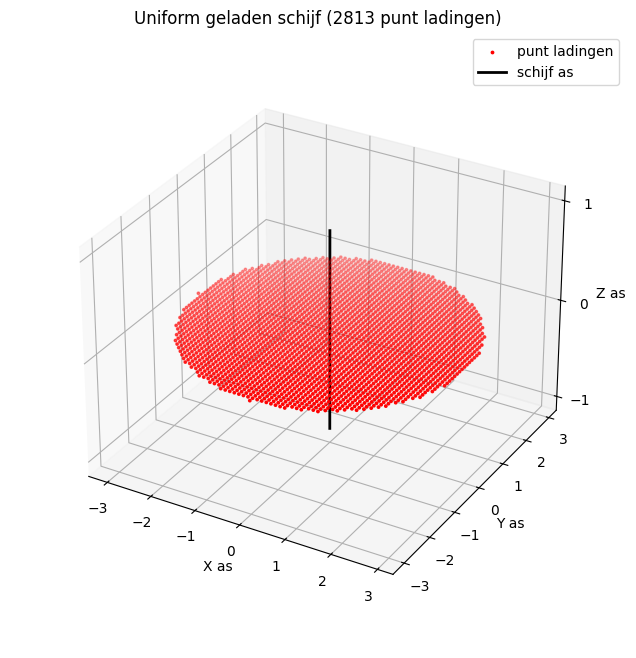

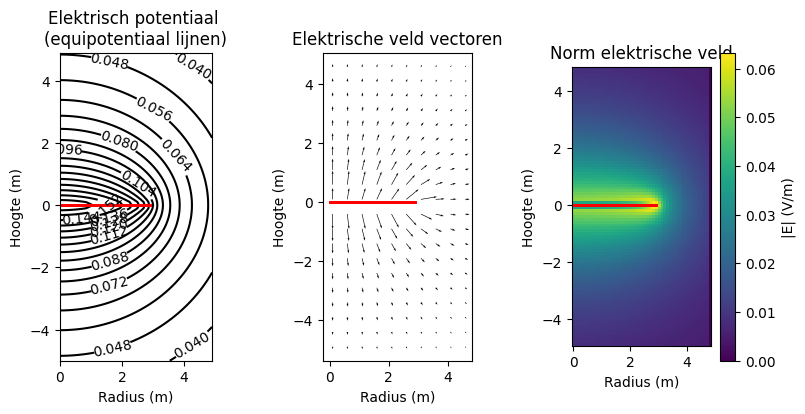

In [6]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. disk radius is simpelweg de straal van de schijf, als deze naar nul gaat is er geen schijf of uberhaupt lading aanwezig.
2. gridstep is de afstand tussen twee puntladingen op de schijf en bepaald dus hoeveel lading er op de schijf zit, een kleinere gridstep zal dus zorgen voor een groter aantal puntlading per $m^2$. Omdat in de simulatie per puntlading berekeningen uitgevoerd worden zal het simuleren bij kleinere gridstep ook langer duren.
3. De variabel z_coord_DISK bepaalt op welke hoogte de schijf zich bevind, in de afbeelding met de equipotentiaallijnen,veldlijnen en veldsterkte zie je dat zowel de schijf als de equipotentiaallijnen,veldlijnen en veldsterkte omhoog/omlaag verplaatsen. In de afbeelding met de schijf gebeurt dit echter niet omdat in de functie 'calculate_V_disk_at_origin_uniform_surface_charge_density' bij de scatter plot de hoogte Z op nul word gezet (0*YY). Hieronder is de vebeterde versie van de code zodat in de plot de schijf en zijn as omhoog en omlaag gaat bij verandering in z_coord_DISK. 

In [7]:
#verbeterde versie code:
def calculate_V_disk_at_origin_uniform_surface_charge_density(z_disk,charge_one_point,disk_radius,inter_charge_distance,r,z):
    x_positions = np.arange(-disk_radius, disk_radius, inter_charge_distance)
    y_positions = np.arange(-disk_radius, disk_radius, inter_charge_distance)
    cnt = 0

    Nr = len(r)
    Nz = len(z)
    V = np.zeros((Nz,Nr))
    Z, R = np.meshgrid(z, r, indexing='ij')

    for xc in x_positions:
        for yc in y_positions:
            if np.sqrt(xc**2+yc**2)<=disk_radius:
                r_charge = np.array([xc, yc, z_disk])
                #r_field = np.array([r, 0, z])
                V += electric_potential_point_charge_cartesian(r_charge, R, Z, charge_one_point)
                cnt += 1

    XX, YY = np.meshgrid(x_positions, y_positions)
    RR_mask = np.sqrt(XX*XX+YY*YY) > disk_radius
    XX[RR_mask] = np.nan
    YY[RR_mask] = np.nan
    
    # Create a figure and 3D axis
    fig = plt.figure(figsize=(8, 8))  # width, height in inches.
    ax = fig.add_subplot(111, projection='3d')
    plt.subplots_adjust(left=0)
    # Create scatter plot
    ax.scatter3D(XX, YY, z_disk, color='red', marker='o', s=3) #-------verandering: 0*YY is nu z_disk-------#
    #ax.view_init(60, 35)
    # Set specific Z-axis ticks
    ax.set_zticks([z_disk-1, z_disk, z_disk+1]) #--------verandering: de as heeft nu ticks gebaseerd op z_disk------#
    ax.plot([0, 0], [0, 0], [z_disk-1, z_disk+1], 'k', linewidth=2)  # vierkante haken om 0,0 toegevoegd #---------verandering: [-1,1] is nu [z_disk-1, z_disk+1] zodat de z_as die geplot wordt afhangt van z_disc 
    #ax.set_zlim(-1, 1)
    ax.legend(['punt ladingen','schijf as'])
    # Labels
    ax.set_xlabel('X as')
    ax.set_ylabel('Y as')
    ax.set_zlabel('Z as')
    ax.set_title(f'Uniform geladen schijf ({cnt:1d} punt ladingen)')
    ax.set_box_aspect(None, zoom=0.88)

    return V, cnt


#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [8]:
q_tot=charge_one_point*number_point_charges_on_disk #totale lading schijf
A=np.pi*disk_radius**2 #oppervlak schijf
sigma=q_tot/A #ladings dichtheid in C/m^2
print("De ladingsdichtheid sigma = %e C/m^2" %(sigma))

De ladingsdichtheid sigma = 9.948952e-13 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

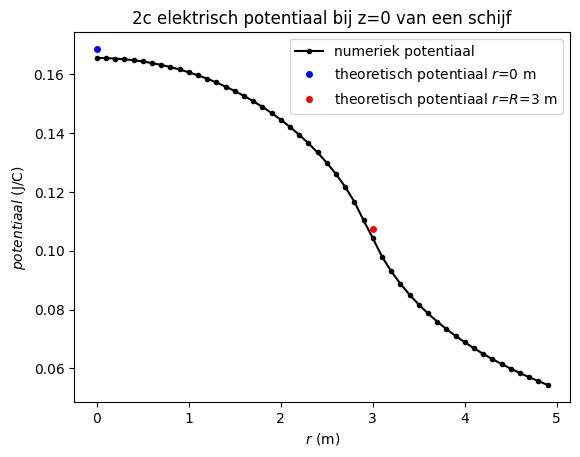

In [9]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
idx_z_zero = find_idx_nearest(0,z)


#uit de functies in functions_electrostatics volgt dat V[i,j]=V(z[i],r[j])
#de data bij z=0:
pot=V[idx_z_zero,] #z=0 is bij idx 50, numeriek potentiaal 

V_0 = sigma*disk_radius/(2*epsilon0) # potentiaal op r = 0
V_R = sigma*disk_radius/(np.pi*epsilon0) # potentiaal op de straal van de schijf
r_R = disk_radius # straal van de schijf

plt.title("2c elektrisch potentiaal bij z=0 van een schijf")
plt.plot(r, pot, "k.-", label="numeriek potentiaal")
plt.plot(0, V_0, "b.", label="theoretisch potentiaal $r$=0 m",ms=8)
plt.plot(r_R, V_R, "r.", label="theoretisch potentiaal $r$=$R$=%d m"%(disk_radius),ms=8)
plt.legend()
plt.xlabel("$r$ (m)")
plt.ylabel("$potentiaal$ (J/C)")
plt.show()



#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


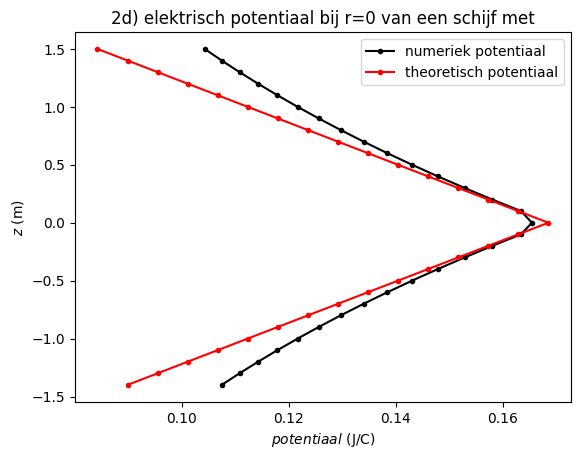

In [10]:
###--------1+2+3-------###
idx_r_zero = find_idx_nearest(0,r)

#uit de functies in functions_electrostatics volgt dat V[i,j]=V(z[i],r[j])
#de data bij z=0:
pot=V[:,idx_r_zero] #numeriek potentiaal op z-as
Vz=sigma*(disk_radius-np.abs(z))/(2*epsilon0) #theoretisch potentiaal 

plt.title("2d) elektrisch potentiaal bij r=0 van een schijf met")
idx=np.abs(z)<0.5*disk_radius #er moet gelden R>>Z
plt.plot(pot[idx],z[idx], "k.-", label="numeriek potentiaal") #z[idx] omdat het theroretisch potentiaal alleen geld voor R>>z
plt.plot(Vz[idx],z[idx],"r.-",label="theoretisch potentiaal") #z[idx] omdat het theroretisch potentiaal alleen geld voor R>>z
plt.legend()
plt.ylabel("$z$ (m)")
plt.xlabel("$potentiaal$ (J/C)")
#plt.savefig("DEF_onlineontwerpopdr_1_condensator_vraag2d_nweR", dpi=300,facecolor='white') #opslaan van de foto, hou deze uitgecomment tijdens runnen van code anders heb je dalijk 20 afbeeldingen
plt.show()

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

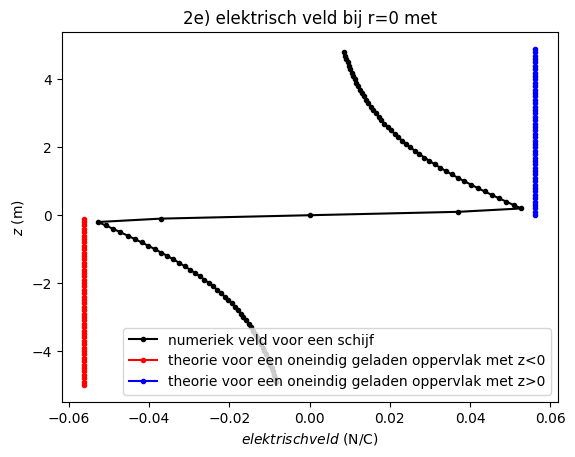

In [11]:
###--------1+2+3-------###
idx_r_zero = find_idx_nearest(0,r)

#uit de functies in functions_electrostatics volgt dat Ez[i,j]=Ez(z[i],r[j])
#de data bij r=0:
veld=Ez[:,idx_r_zero] #numerieke elektrischveld op z-as
E_min=np.repeat(-sigma/(2*epsilon0),len(z[:idx_z_zero])) #theorie voor z<0
E_plus=np.repeat(sigma/(2*epsilon0),len(z[idx_z_zero:])) #theorie voor Z>0


plt.title("2e) elektrisch veld bij r=0 met")
plt.plot(veld,z_for_E, "k.-", label="numeriek veld voor een schijf") 
plt.plot(E_min,z[:idx_z_zero],"r.-",label="theorie voor een oneindig geladen oppervlak met z<0")
plt.plot(E_plus,z[idx_z_zero:],"b.-",label="theorie voor een oneindig geladen oppervlak met z>0")
plt.ylabel("$z$ (m)")
plt.xlabel("$elektrisch veld$ (N/C)")
plt.legend(loc="lower right")
#plt.savefig("DEF_onlineontwerpopdr_1_condensator_vraag2e_nweR", dpi=300,facecolor='white') #opslaan van de foto, hou deze uitgecomment tijdens runnen van code anders heb je dalijk 20 afbeeldingen
plt.show()


#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

1. op z=0 benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat.
2. In de plot is te zien dat naarmate je hoger of lager gaat bij een schijf het elektrisch veld naar nul nadert terwijl bij een oneindig geladen oppervlak het elektrisch veld constant blijft. Bij zowel de schijf als het oneindig geladen oppervlak neemt de invloed van één specifieke puntlading af naarmate je omhoog of omlaag langs de z-as beweegt. Het verschil zit in het feit dat bij een oneidig geladen oppervlak deze afname wordt gecompenseerd doordat er steed meer puntladingen een invloed gaan hebben waardoor het elektrisch veld constant blijft, bij een schijf stopt het aantal puntladingen uiteindlijk dus zal het elektrischveld afnemen naar nul.




#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

afbeeldingen van de nieuwe straal:


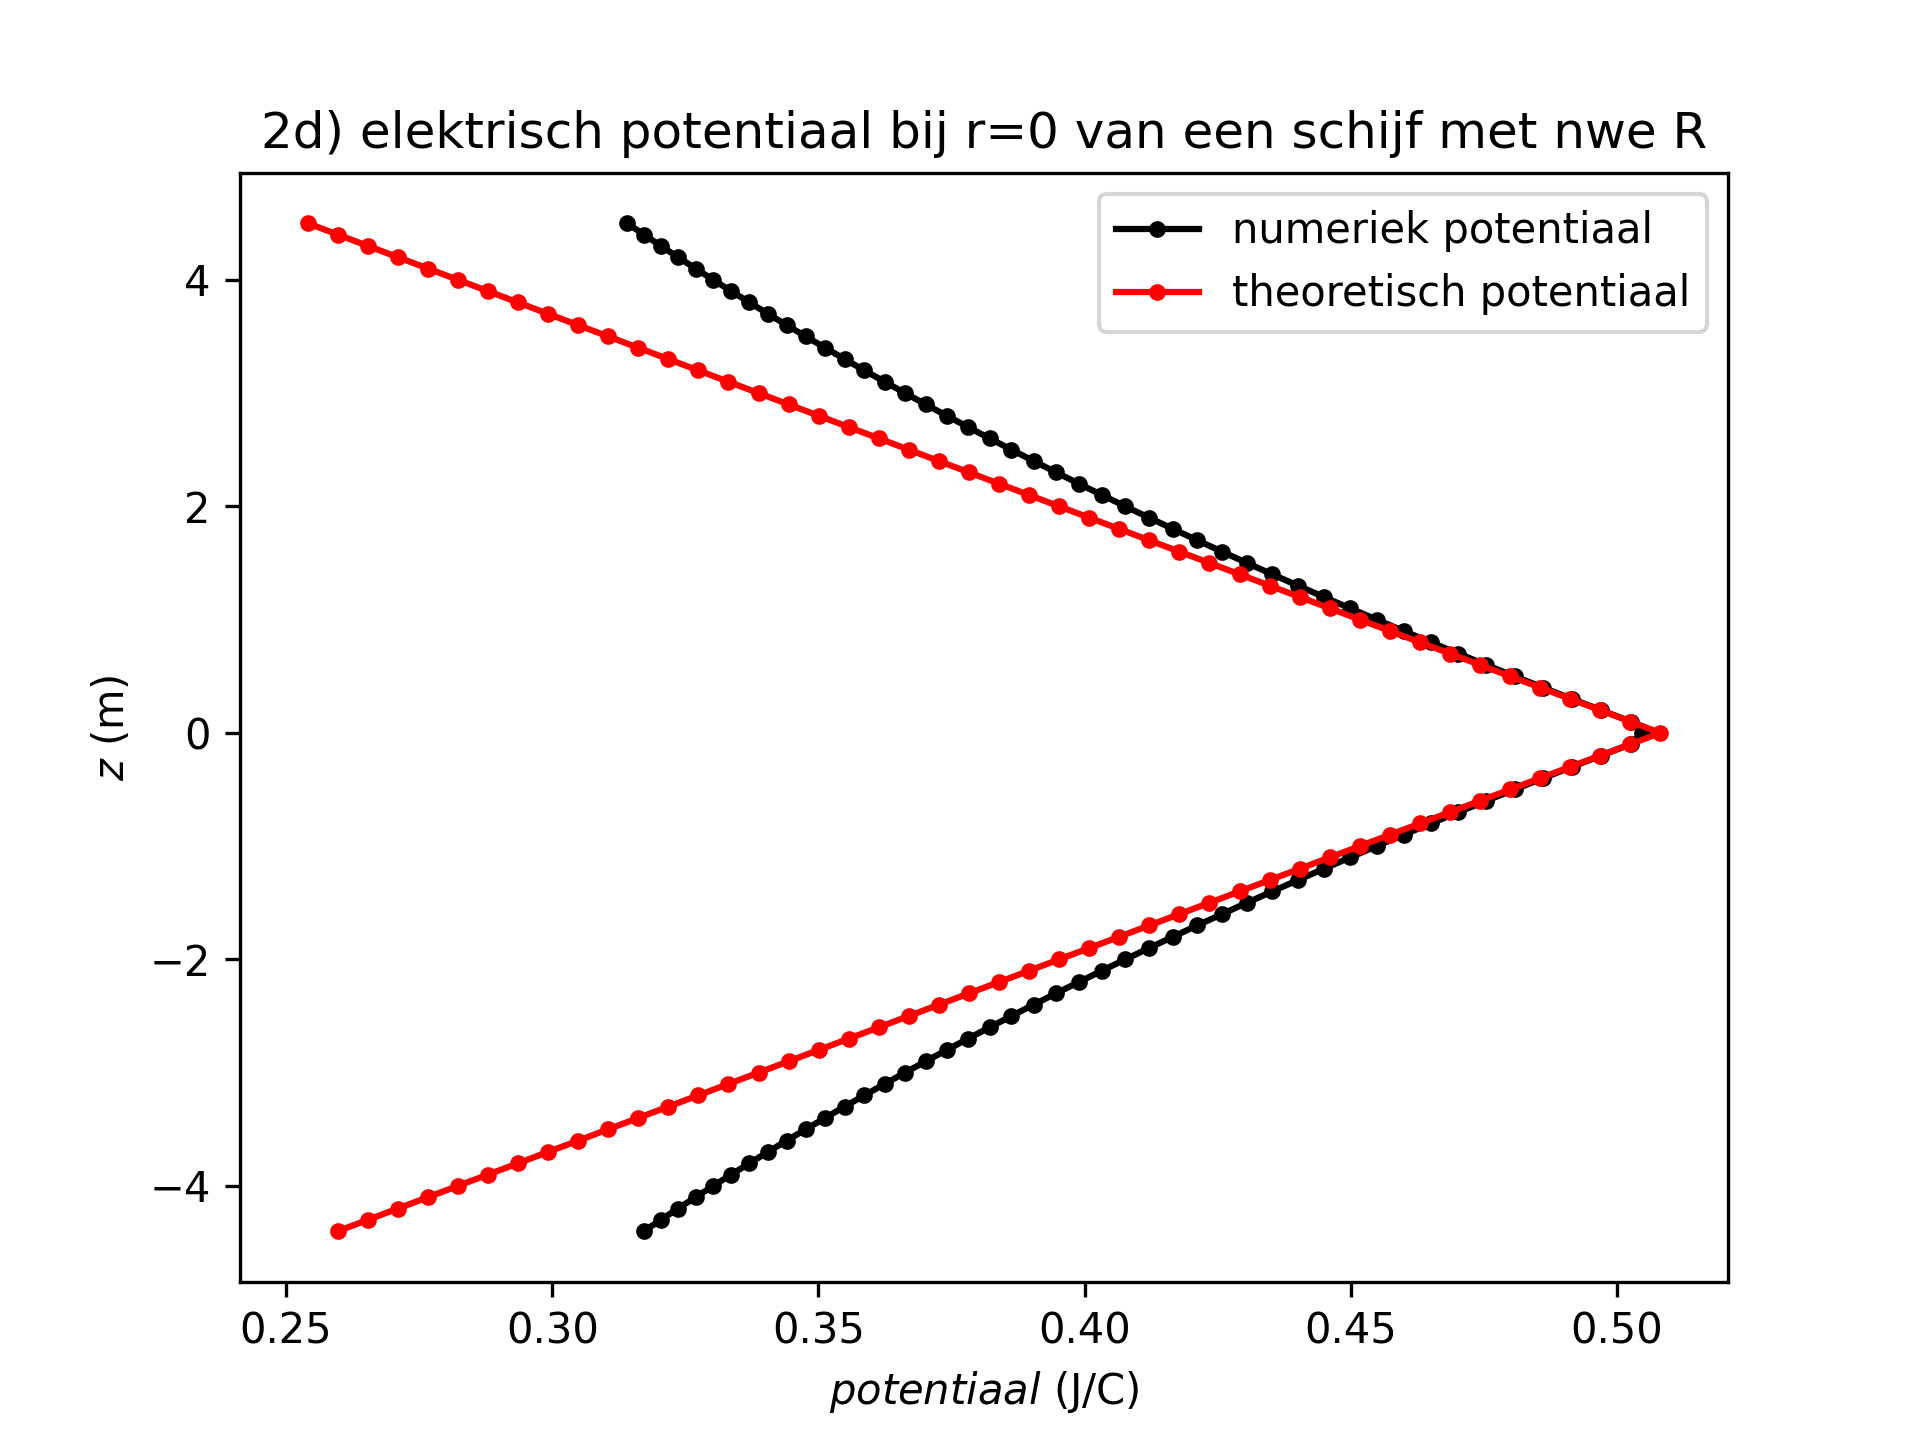

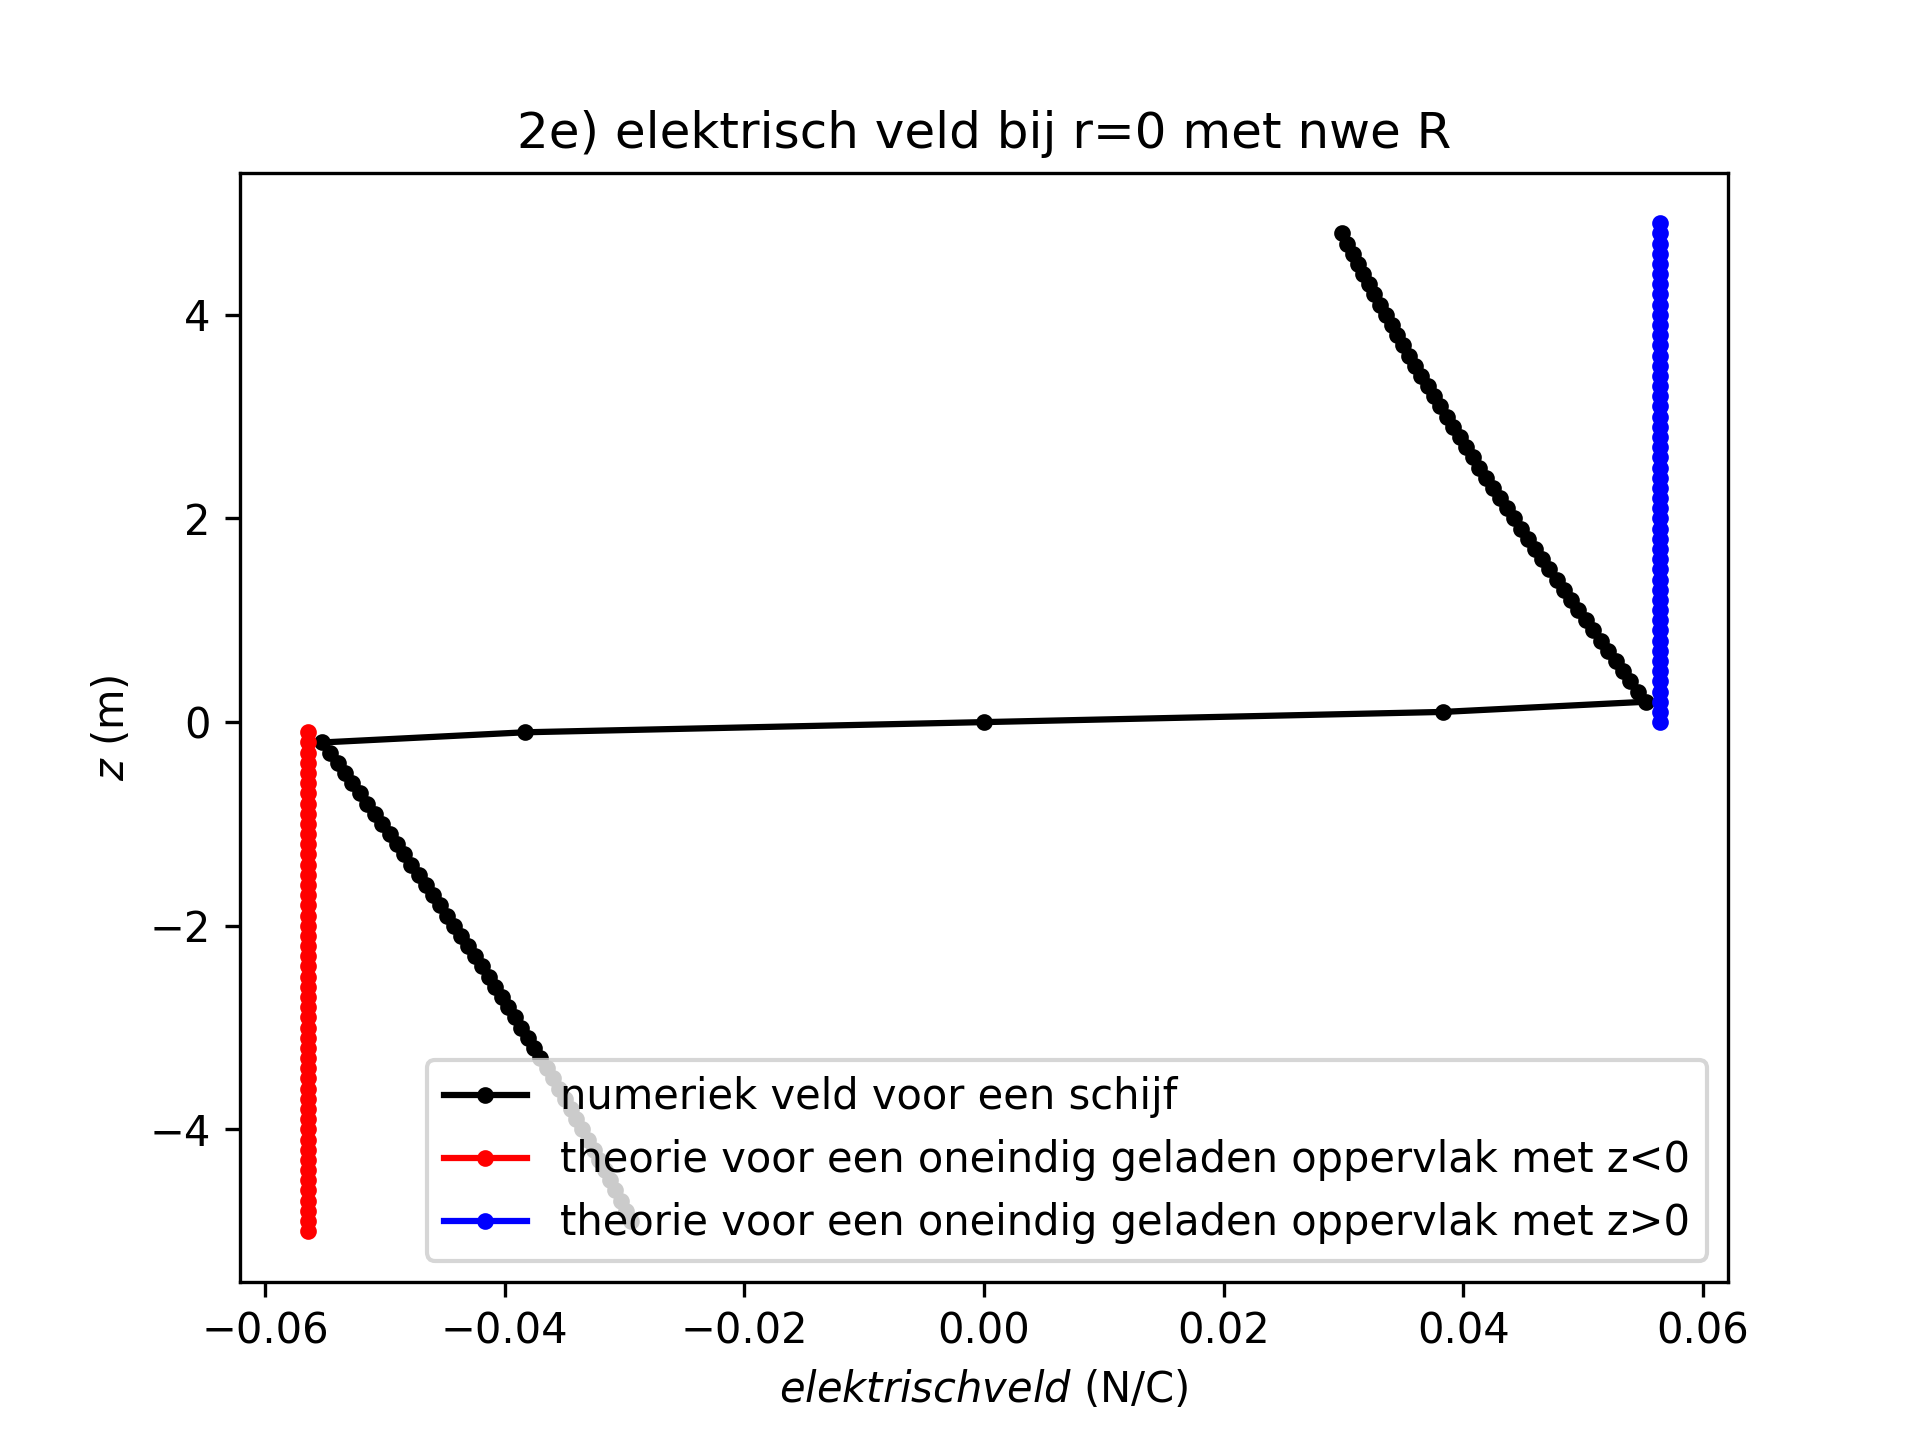

afbeeldingen van de oorsprongelijke straal:


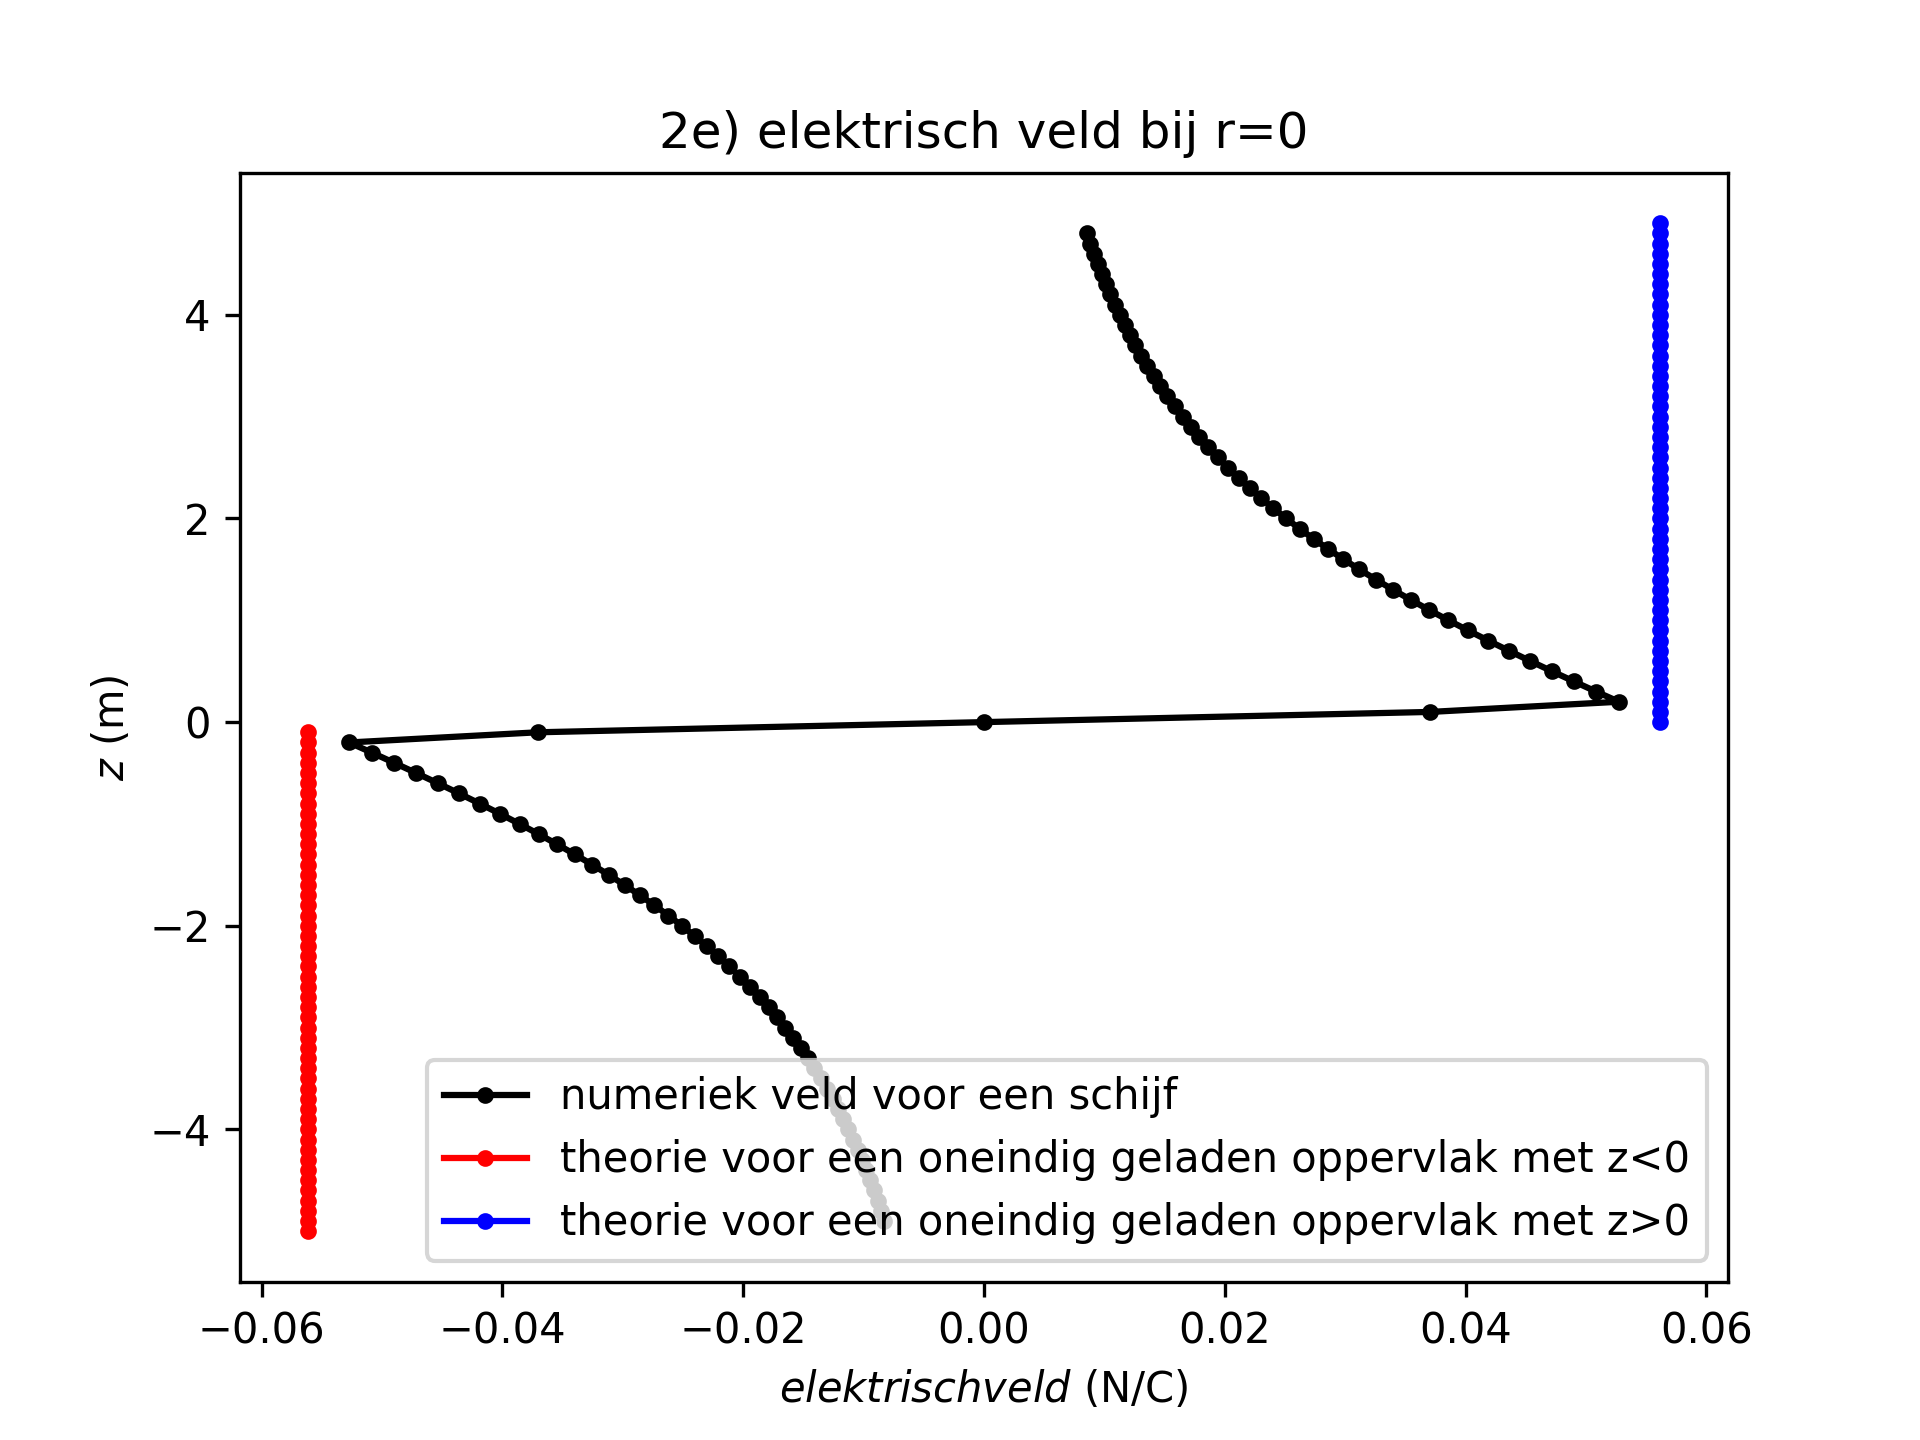

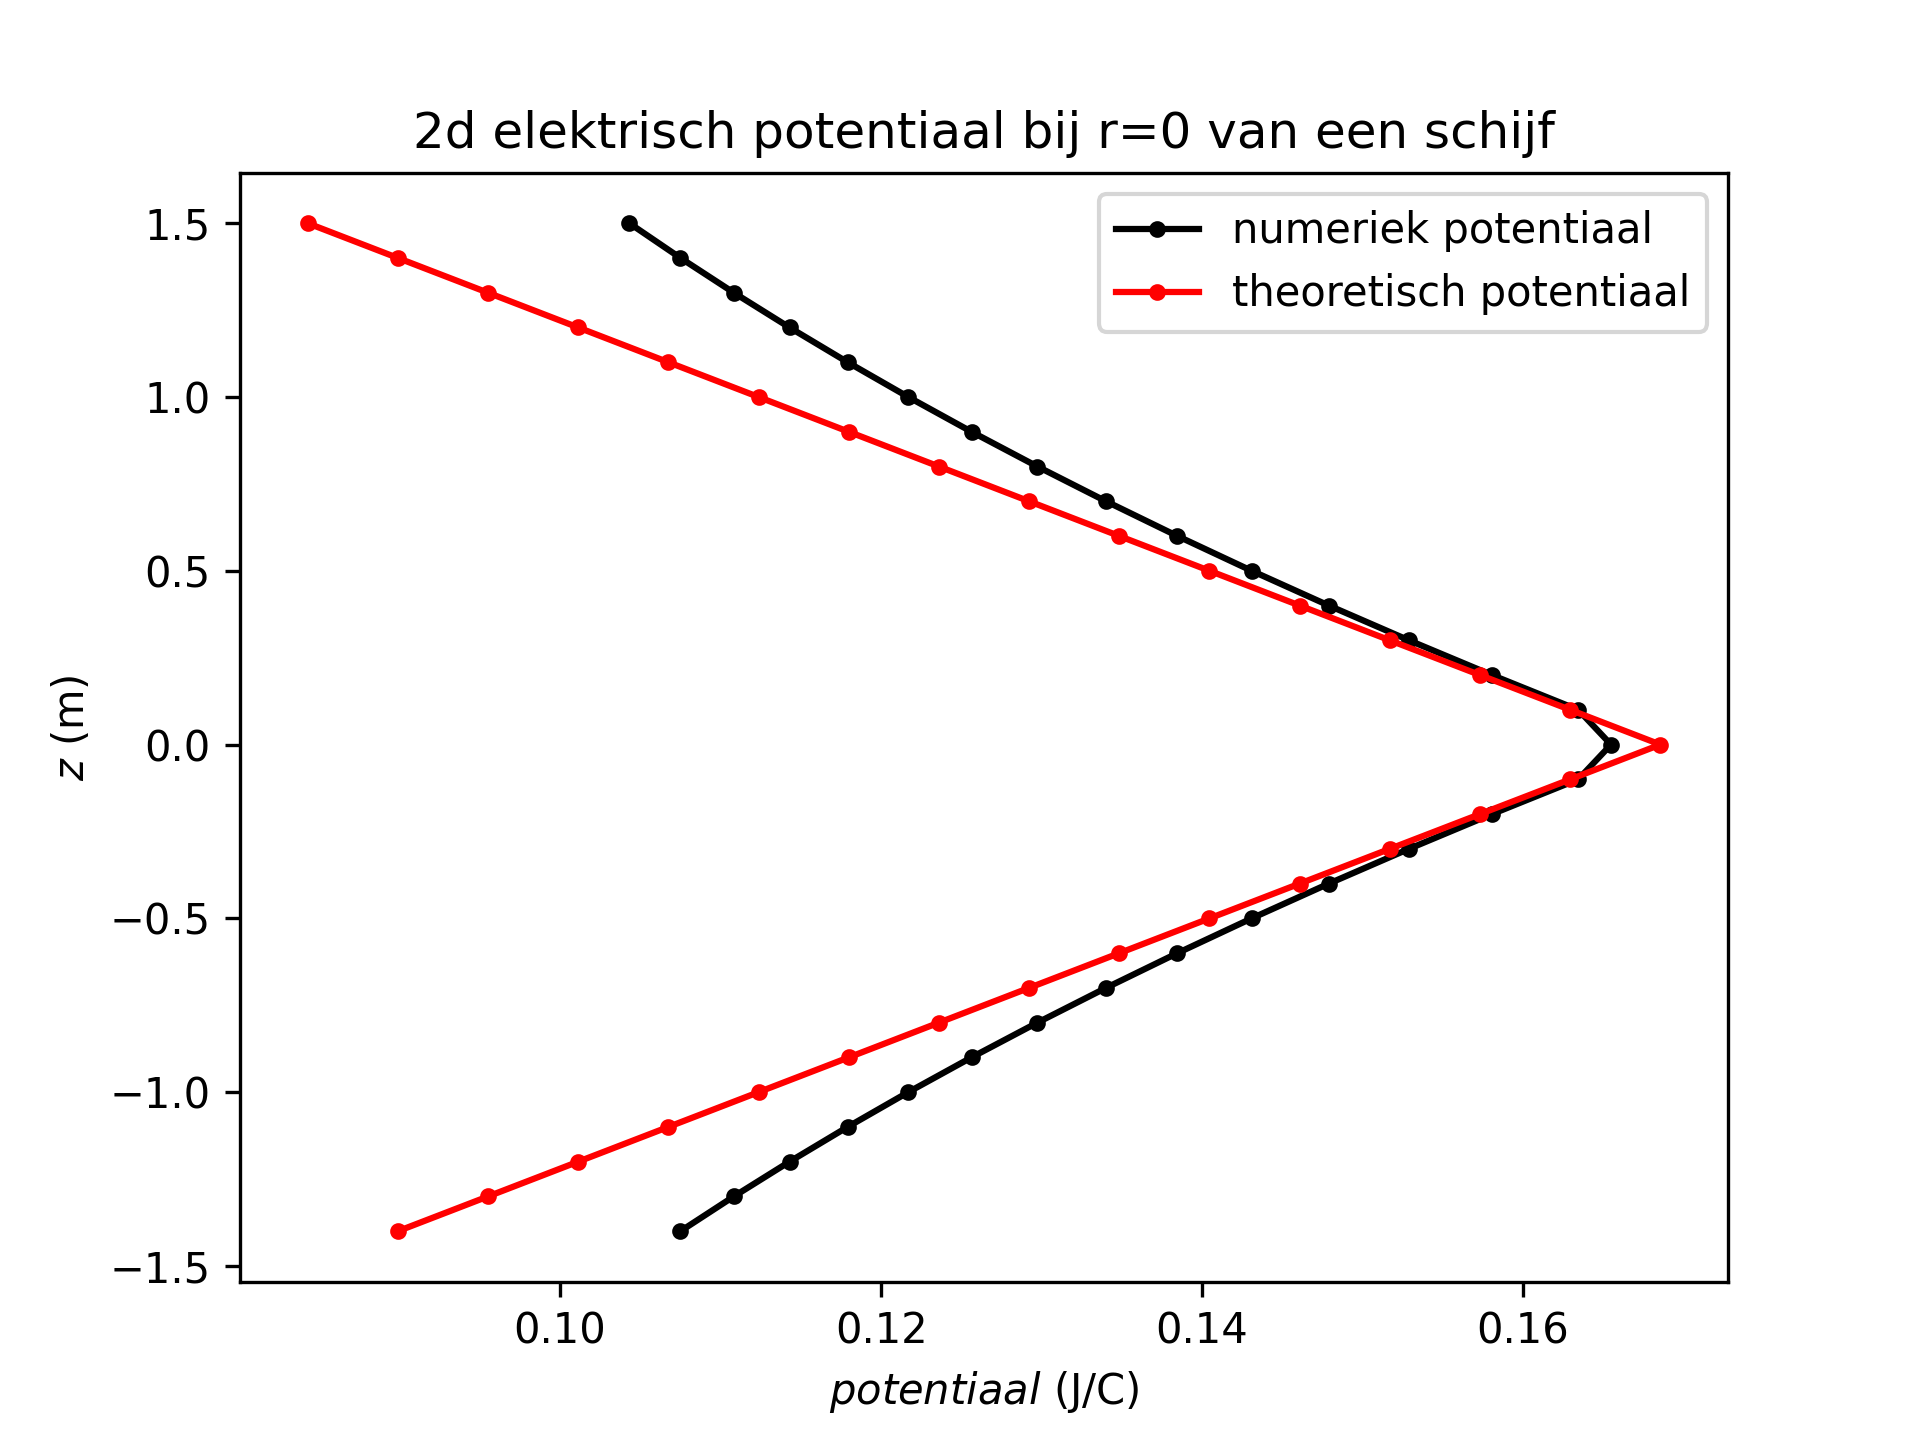

In [12]:
###-----1,2,3------#
fg=500
print("afbeeldingen van de nieuwe straal:")
display(Image(r"./DEF_onlineontwerpopdr_1_condensator_vraag2d_nweR.png"
,width=fg))
display(Image(r"./DEF_onlineontwerpopdr_1_condensator_vraag2e_nweR.png"
,width=fg))
print("afbeeldingen van de oorsprongelijke straal:")
display(Image(r"./DEF_onlineontwerpopdr_1_condensator_vraag2e.png"
,width=fg))
display(Image(r"./DEF_onlineontwerpopdr_1_condensator_vraag2d.png"
,width=fg))

##### Antwoorden 2g
4. De nieuwe straal is drie keer zo groot als de oorsprongkelijke, in het verschil tussen de figuren is te zien dat de schijf met de grotere straal zich meer gedraagt als een oneindig geladen oppervlak wat natuurlijk logisch is omdat je bij de grotere schijf meer puntlading hebt bij gelijke ladingsdichtheid.

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h
$$
\begin{aligned}
    \frac{\sigma}{2\epsilon_0} ( 1- \frac{z}{\sqrt{R^2 + z^2}})=a\frac{\sigma}{2\epsilon_0} \\
    ( 1- \frac{z}{\sqrt{R^2 + z^2}})=a\\
    \frac{z}{\sqrt{R^2 + z^2}}=(1-a)\\
    z=(1-a)\sqrt{R^2 + z^2}\\
    z^2=(1-a)^2(R^2 + z^2)\\
    (1-(1-a)^2)z^2=(1-a)^2R^2\\
    (2a-a^2)z^2=(1-a)^2R^2\\
    z^2=\frac{(1-a)^2}{2a-a^2}R^2\\
\end{aligned}
$$
Boven de schijf dus z>0:

$$
\begin{aligned}
    z=\frac{1-a}{\sqrt{2a-a^2}}R 
\end{aligned}
$$
voor a=0.1(10%):
$$
\begin{aligned}
    z=\frac{1-0.1}{\sqrt{2\cdot 0.1-0.1^2}}R=\frac{0.9}{\sqrt{0.19}}R=2.064\dots R
\end{aligned}
$$

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

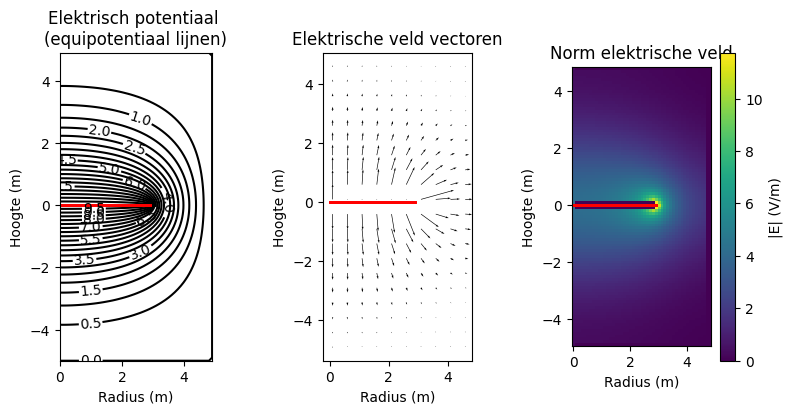

In [13]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

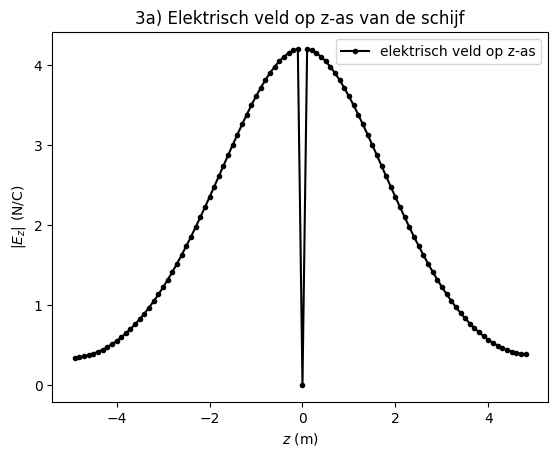

De elektrische veldsterkte heel dicht bij midden van de schijf, dus op r ≈ 0 en z ≈ 0 is E = 4.202e+00 N/C


In [14]:
#--3a--#
# vind eerst de index waar r = 0
idx_r_zero = find_idx_nearest(r_for_E,0)
# dan halen we de sterkte van e-veld op z as op die index
E_norm_z = normE[:,idx_r_zero]

# plotten van E_z_as tegen z_for_E
plt.figure()
plt.plot(z_for_E,E_norm_z,"k.-",label="elektrisch veld op z-as")
plt.xlabel("$z$ (m)")
plt.ylabel("$|E_z|$ (N/C)")
plt.title("3a) Elektrisch veld op z-as van de schijf")
plt.legend()
plt.show()

idx_z_near_zero = find_idx_nearest(z,0)
normE_near_middel = normE[idx_z_near_zero,idx_r_zero]
print(f"De elektrische veldsterkte heel dicht bij midden van de schijf, dus op r \u2248 0 en z \u2248 0 is E = {normE_near_middel:.3e} N/C")

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

*Geef in deze markdown cel je antwoord op 3b.1.*

We weten dat binnen een geleider is $E=0$, dus om E op het midden te benaderen moeten we kijken naar $E_\perp$
We weten dat volgense Gauss wet:
$$
\oint E \cdot dA = \frac{Q_{enc}}{\epsilon_0}
$$
We moeten kijken naar $E^{boven}_\perp$, $E^{onder}_\perp$ en $E_{zijkant}$, omdat $E_{zijkant}$ verwaarloosbaar is:
$$
\oint E \cdot dA = E^{boven}_\perp \cdot \Delta A - E^{onder}_\perp \Delta A
$$
We weten ook dat 
$$
Q_{enc} = \sigma \cdot \Delta A
$$
Dus 
$$
E^{boven}_\perp \cdot \Delta A - E^{onder}_\perp \Delta A = \frac{\sigma\Delta A}{\epsilon_0}
$$
Deel door $\Delta A$
$$
E^{boven}_\perp  - E^{onder}_\perp= \frac{\sigma}{\epsilon_0}
$$
Voor een geleider geldt $E^{onder}_\perp = 0$
Dus 
$$
\sigma = \epsilon_{0}E^{boven}_\perp
$$


In [15]:
#### Print met deze cel met een nette opmaak je antwoord op vraag 3b 2.
epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)
# we moeten E_z net boven de schijf nemen
E_just_above = normE[idx_z_near_zero,idx_r_zero]
sigma = epsilon0*E_just_above

print(f"De ladingsdichtheid op de schijf is sigma = {sigma:.3e} C/m^2")

De ladingsdichtheid op de schijf is sigma = 3.720e-11 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


Totale lading Q = 2.104e-09 C
σ_centrum (geleidend) = 3.720e-11 C/m²
σ_uniform (uniform) = 7.441e-11 C/m²
Verhouding: σ_centrum / σ_uniform = 0.500


<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Muean\AppData\Local\Temp\ipykernel_22640\3119022423.py:26: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sigma(r)$ (C/m²)")


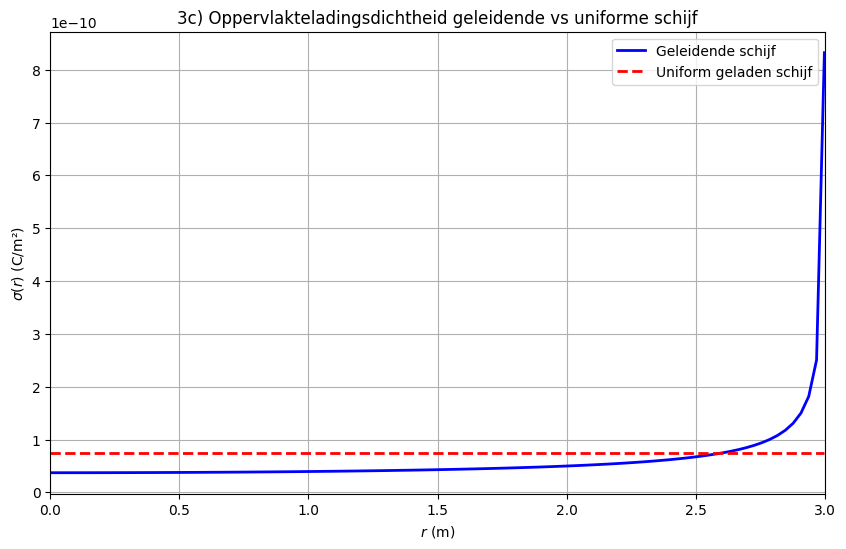

In [16]:
###
###Jouw code hier###
###
# Bij de centrum is r = 0, dus r in bovenstaande formule valt weg
q_total = 2 * np.pi*disk_radius**2*sigma
sigma_uniform = q_total / (np.pi * disk_radius**2)
ratio = sigma / sigma_uniform

print(f"Totale lading Q = {q_total:.3e} C")
print(f"σ_centrum (geleidend) = {sigma:.3e} C/m²")
print(f"σ_uniform (uniform) = {sigma_uniform:.3e} C/m²")
print(f"Verhouding: σ_centrum / σ_uniform = {ratio:.3f}")

r_range = np.linspace(0.001, disk_radius*0.999, 100)  # vermijd r=0 en r=R (gedeeld door 0)

# Geleidende schijf (Griffiths formule)
sigma_conducting = q_total / (2 * np.pi * disk_radius * np.sqrt(disk_radius**2 - r_range**2))

# Uniforme schijf (constant)
sigma_uniform_array = np.ones_like(r_range) * sigma_uniform

plt.figure(figsize=(10, 6))
plt.plot(r_range, sigma_conducting, 'b-', linewidth=2, label='Geleidende schijf')
plt.plot(r_range, sigma_uniform_array, 'r--', linewidth=2, label='Uniform geladen schijf')
plt.xlabel("$r$ (m)")
plt.ylabel("$\sigma(r)$ (C/m²)")
plt.title("3c) Oppervlakteladingsdichtheid geleidende vs uniforme schijf")
plt.legend()
plt.grid(True)
plt.xlim(0, disk_radius)
plt.show()


#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [17]:
# Deze cel kan je gebruiken om van vraag 3c 1 tot en met 4 te beantwoorden.
max_E = np.max(normE)
print(f"Het maximale elektrische veld in het domein is E = {max_E:.3e} N/C")
max_E_idx = np.unravel_index(np.argmax(normE), normE.shape)
r_max_E = r_for_E[max_E_idx[1]]
z_max_E = z_for_E[max_E_idx[0]]
print(f"Het maximale elektrische veld bevindt zich bij r = {r_max_E:.3f} m en z = {z_max_E:.3f} m")
ratio = max_E / normE_near_middel
print(f"Dit maximale veld is ongeveer {ratio:.3e} keer hoger dan het veld in het midden van de schijf de schijf")
print("Straal van de schijf is %d m"%(disk_radius))

Het maximale elektrische veld in het domein is E = 1.175e+01 N/C
Het maximale elektrische veld bevindt zich bij r = 3.000 m en z = 0.100 m
Dit maximale veld is ongeveer 2.797e+00 keer hoger dan het veld in het midden van de schijf de schijf
Straal van de schijf is 3 m


##### Antwoord 3d.5

We zien dat het maximale elektrische veld zich op $r=3.0m$ bevindt, deze is gelijk aan de straal van de schijf. Dus het maximale e-veld bevindt zicht aan de rand van de schijf. Daar benadert r R. Uit bovenstaande formule voor ladingsdichtheid is te concluderen dat als $r\rightarrow R$ dan $\sigma \rightarrow \infty$

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

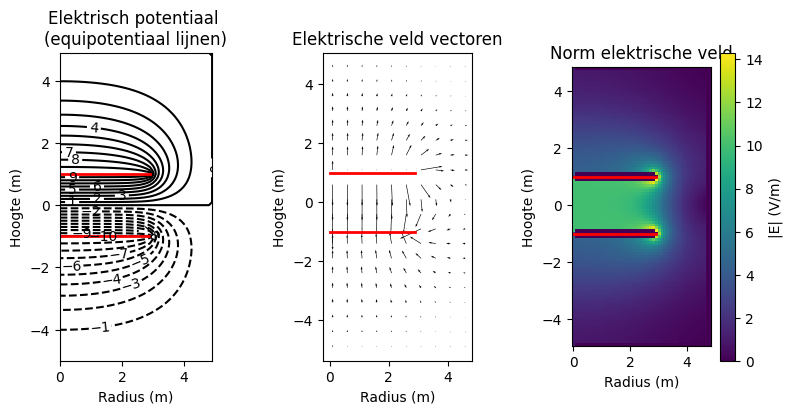

In [18]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


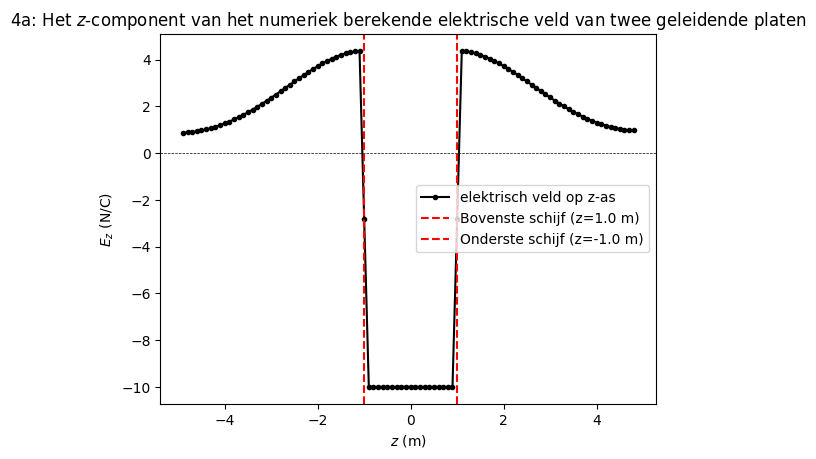

In [19]:
###
###your code here###
###
idx_at_z_as = find_idx_nearest(r, 0)
Ez_at_z_as = Ez[:, idx_at_z_as]
plt.figure()
plt.plot(z_for_E, Ez_at_z_as, "k.-", label="elektrisch veld op z-as")
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.axvline(x=z_pos_disk1, color='r', linestyle='--', label=f'Bovenste schijf (z={z_pos_disk1} m)')
plt.axvline(x=z_pos_disk2, color='r', linestyle='--', label=f'Onderste schijf (z={z_pos_disk2} m)')
plt.xlabel("$z$ (m)")
plt.ylabel("$E_z$ (N/C)")
plt.title("4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen")
plt.legend()
plt.show()

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b
We weten dat
$$
V(\vec{r}) = - \int_{ref}^{\vec{r}} \vec{E} \cdot d\vec{l} 
$$
Dus E is dan
$$
\vec{E} = -\nabla V
$$
Tussen twee platen geld $V(z) = az+b$
De helling is $a=\frac{V_2-V_1}{-d}$, dan vullen we ook $z=d/2$ en $V = V_1$ in de formule, we krijgen dan $b = \frac{V_1+V_2}{2}$.
Na herschrijven krijgen we:
$$
V(z) = V_1 = \frac{V_1-V_2}{d}(z-d/2)
$$
Bij deze situatie geldt $V_2 = -V_1$, dus:
$$
V(z) = V_1 - \frac{2V_1}{d}(z-d/2)
$$
Na herschijving:
$$
V(z) = -\frac{2V_1}{d}z+2V_1
$$
Rond $z=0$:
$$
V(z) = -\frac{2V_1}{d}z
$$
In dit geval kijken we alleen naar de partiele afgeleide met $z$, dus voor tussen twee platen geldt:
$$
E = \frac{\Delta V}{d}
$$
In dit geval is $\Delta V = 2V_1$, dus:
$$
E = \frac{2V_1}{d}
$$
Is de electrische veld tussen twee platen,

Buiten de twee platen geldt $E=0$





In [20]:
E_theoretical = (V1 - V2) / spacing_between_disks
idx_r_zero = find_idx_nearest(r_for_E, 0)

idx_z1 = find_idx_nearest(z_for_E, z_pos_disk1)
idx_z2 = find_idx_nearest(z_for_E, z_pos_disk2)
idx_z_center = find_idx_nearest(z_for_E, 0)

Ez_between_disks = Ez[idx_z2:idx_z1+1, idx_r_zero]
E_numeric = abs(Ez[idx_z_center, idx_r_zero])

print("4b.2:")
print(f"Theoretisch E-veld tussen platen: {E_theoretical:.3e} V/m")
print(f"Numeriek E-veld in midden (afgeleid met Laplacevergelijking) (z=0): {E_numeric:.3e} V/m")
print(f"Verschil: {abs(E_numeric - E_theoretical):.3e} V/m")
print(f"Relatieve fout: {abs(E_numeric - E_theoretical)/E_theoretical*100:.2f}%")

print("4b.3:")
print(f"E in het midden van enkele schijf (vraag 3b): {normE_near_middel:.3e} N/C")
print(f"E in het midden tussen twee schijven: {E_numeric:.3e} N/C")
print(f"Met twee schijven is het veld in het midden ongeveer {E_numeric/normE_near_middel:.3} keer sterker dan bij een schijf")


4b.2:
Theoretisch E-veld tussen platen: 1.000e+01 V/m
Numeriek E-veld in midden (afgeleid met Laplacevergelijking) (z=0): 9.996e+00 V/m
Verschil: 4.223e-03 V/m
Relatieve fout: 0.04%
4b.3:
E in het midden van enkele schijf (vraag 3b): 4.202e+00 N/C
E in het midden tussen twee schijven: 9.996e+00 N/C
Met twee schijven is het veld in het midden ongeveer 2.38 keer sterker dan bij een schijf


4b.3:

We zien dat met twee platen de elekrische veldsterkte 2.38 keer sterker is dan met een schijf. Bovendien is het veld tussen de schijven constant, terwijl bij enkele schijf het veld sterk afhangt met z.

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [21]:
###
###your code here###
###

sigma_inside = epsilon0 * E_theoretical
print(f"De verwachte oppervlakteladingsdichtheid op de binnnenzijde van een schijf is {sigma_inside:.3e} C/m^2")
q_disk = sigma_inside * np.pi * disk_radius**2
print(f"De totale lading op de schijf is dan Q = {q_disk:.3e} C")
capacity = q_disk / (V1 - V2)
print(f"De capaciteit van deze condensator is C = {capacity:.3e} C/V")

De verwachte oppervlakteladingsdichtheid op de binnnenzijde van een schijf is 8.854e-11 C/m^2
De totale lading op de schijf is dan Q = 2.503e-09 C
De capaciteit van deze condensator is C = 1.252e-10 C/V


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

We zien dat uit de simulatie van 4a, is de elektrische veld niet 0 is, en we hebben afgeleid dat $\sigma=\epsilon_0E_{\perp}^{buiten}$, dus $\sigma$ kan geen nul zijn. Maar theoretisch gezien is $E=0$ buiten de geleider, dus dan is $\sigma$ wel nul.

Het elektrische veld nabij het oppervlak van een geleider staat altijd loodrecht boven het oppervlak. En er geldt $E = \frac{\sigma}{\epsilon_0}$

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [22]:
###
###Your code here###
###
idx_under = np.where(z_for_E < z_pos_disk2)[0][-1]
Ez_under = Ez[idx_under, idx_r_zero]
sigma_under = epsilon0 * abs(Ez_under)

idx_above = np.where(z_for_E > z_pos_disk2)[0][0]
Ez_above = Ez[idx_above, idx_r_zero]
sigma_above = epsilon0 * abs(Ez_above)

print(f"E_z op z-as net onder onderste schijf: {Ez_under:.3e} N/C, ladingsdichtheid daar: {sigma_under:.3e} C/m^2")
print(f"E_z op z-as net boven onderste schijf: {Ez_above:.3e} N/C, ladingsdichtheid daar: {sigma_above:.3e} C/m^2")
print(f"ratio van ladingsdichtheid onder en boven de schijf: {sigma_under/sigma_above:.3f}")

E_z op z-as net onder onderste schijf: -2.810e+00 N/C, ladingsdichtheid daar: 2.488e-11 C/m^2
E_z op z-as net boven onderste schijf: -1.000e+01 N/C, ladingsdichtheid daar: 8.858e-11 C/m^2
ratio van ladingsdichtheid onder en boven de schijf: 0.281


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

In [23]:
sigma_total = sigma_under + sigma_above
q_real = sigma_total * np.pi * disk_radius**2
print(f"De daadwerkelijke totale lading op de schijf, gebaseerd op het veld net onder en boven de schijf, is Q = {q_real:.3e} C")
print(f"Deze is {q_real/q_disk:.3f} keer de lading die we verwachtten op basis van het veld tussen de schijven (4c)")

De daadwerkelijke totale lading op de schijf, gebaseerd op het veld net onder en boven de schijf, is Q = 3.208e-09 C
Deze is 1.281 keer de lading die we verwachtten op basis van het veld tussen de schijven (4c)


##### Antwoorden 4f

1. We zien dat totale lading, berekend op basis van veld net onder en net boven de schijf 1.281 keer groter is dan what we hebben berekend in vraag 4c. Dit gebeurt omdat in vraag 4c werd aangenomen dat er alleen lading aan de binnenkant zit en geen lading aan de buitenkant, echter is het niet de geval voor oneindige platen.

2. De capaciteit is berekend met $C = \frac{Q}{\Delta V}$, omdat de daadwerkelijke lading op de schijf groter is, zou de capaciteit berekend in 4c ook toenemen.

3. 
| Parameter | d = 2 m | d = 1 m |
|-----------|---------|---------|
| $E_{\text{binnen}}$ | 10.0 V/m | 20.0 V/m |
| $\sigma_{\text{binnen}}$ | $8.86 \times 10^{-11}$ C/m² | $1.77 \times 10^{-10}$ C/m² |
| $E_{\text{buiten}}$ | 2.81 V/m | 7.82 V/m |
| $\sigma_{\text{buiten}}$ | $2.49 \times 10^{-11}$ C/m² | $6.92 \times 10^{-11}$ C/m² |
| Ratio $\sigma_{\text{buiten}}/\sigma_{\text{binnen}}$ | 0.281 | 0.391 |
| $Q_{\text{werkelijk}}/Q_{\text{theorie}}$ | 1.281 | 1.391 |


Bij kleinere afstand (d = 1 m i.p.v. 2 m):

- Het E-veld tussen de platen verdubbelt (van 10 naar 20 V/m), dus $\sigma_{binnen}$ verdubbelt ook
- Het E-veld aan de buitenkant neemt onevenredig toe (factor 2.78), dus $\sigma_{buiten}$ stijgt sterker dan $\sigma_{buiten}$
- De ratio $\sigma_{buiten}/\sigma_{binnen}$ stijgt van 0.281 naar 0.391
- Het verschil tussen werkelijke en theoretische lading wordt groter, van 1.28× naar 1.39×

Dus bij kleinere afstand worden randeffecten dominanter (ladingsdichtheid buiten wordt een grotere deel op totale ladingsdichtheid), waardoor de ideale 
plaat formule $C = \epsilon_0 A / d$ een slechter benadering wordt voor schijven met eindige straal.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [24]:
def vlakkeplaat(epsilon,L,B,d):
    '''
    epsilon = permitiviteit medium
    L = lengte in m
    B = breedte in m
    d = afstand tussen platen in m
    '''
    C = epsilon*B*L/d 
    return C

def cilinder(epsilon,L,a,b):
    '''
    epsilon = permitiviteit medium
    L = lengte in m
    a = binnenstraal in m
    b = buitenstraal in m
    '''
    C = 2*np.pi*epsilon*L/np.log(b/a)
    return  C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [39]:
###
###your code here###
###
epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)
c1 = vlakkeplaat(epsilon0, 0.1, 0.1, 0.001)
print("5b1: ", c1)
c2 = cilinder(epsilon0, 0.1, 0.009/2, 0.01/2)
print("5b2: ", c2)
c3_1 = vlakkeplaat(epsilon0, 0.1, 0.1, 0.002)
c3_2 = cilinder(epsilon0, 0.1, 0.009/2, 0.02/2)
print("5b3: ", c3_1, c3_2)
epsilon_water = 8.854e-12 * 80 #F/m
epsilon_pvc = 3.54e-11
c4_1 = vlakkeplaat(epsilon_water, 0.1, 0.1, 0.001)
c4_2 = cilinder(epsilon0, 0.1, 0.009/2, 0.01/2)
print("5b4: ", c4_1, c4_2)
c5_1 = vlakkeplaat(epsilon_pvc, 0.1, 0.1, 0.001)
c5_2 = cilinder(epsilon_pvc, 0.1, 0.009/2, 0.01/2)
print("5b5: ", c5_1, c5_2)


5b1:  8.854e-11
5b2:  5.280092106841892e-11
5b3:  4.427e-11 6.966911273776389e-12
5b4:  7.0832e-09 5.280092106841892e-11
5b5:  3.5400000000000007e-10 2.1110826810729956e-10


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [38]:
###
###Jouw code hier###
###
a = 0.005/2
b = 0.006/2
c = 1e-6
L = np.log(b/a)*c / (2*np.pi*epsilon0)
print("5c1: ", L)

C = 1e-6
B = 0.006
d = 0.0005
epsilon0 = 8.854e-12
L = C*d / (epsilon0*B)
print("5c2: ", L)

5c1:  3277.3183867142097
5c2:  9411.941871847


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

*Beantwoord hier de vraag 5d.*

Deze zijn niet realistisch. Een condensatr van order van grote van milimeter kan geen lengte van killometers hebben.

Deze is te verklaren omdat ten eerste er een bij de ruimte tussen de platen vaak een materiaal met grotere permittiviteit $\epsilon_0$ wordt gevuld, waardoor de berekend length met behulp van bovenstaande formule afneemt. Daarnaast is bij moderne condensatoren de afstand tussen de platten in order van micrometers ipv millimeters

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [37]:
###
###Jouw code hier###
###
M = 2000 #kg
print(f"Massa van de een treinje met 6 personen is geschat is {M} kg")
v = 70 / 3.6 #m/s
E_k = 0.5*M*v**2 # J
print(f"De totale energie na afschieten van het treinje is E_k = {E_k:.3e} J")
V = 10000 #V
C = 2*E_k / (V**2) #F/m
print(f"De totale capaciteit van de condensator is C = {C:.3e} F")
d = 0.001 #m
epsilon_water = 8.854e-12 * 80 #F/m
A = C*d/epsilon_water
print(f"Het oppervlakte van een vlakke plaat condesato die deze capaciteit heeft als die ingevuld is met water en de platen 1 mm van elkaar afstaan is  A = {A:.3e} m^2")


Massa van de een treinje met 6 personen is geschat is 2000 kg
De totale energie na afschieten van het treinje is E_k = 3.781e+05 J
De totale capaciteit van de condensator is C = 7.562e-03 F
Het oppervlakte van een vlakke plaat condesato die deze capaciteit heeft als die ingevuld is met water en de platen 1 mm van elkaar afstaan is  A = 1.068e+04 m^2


Deze is niet realischtische, de oppervlakte berekend is $10680m^2$, deze is ongeveer 2 voetbalvelden. Maar deze zou misschien kunnen als de capacitoren opgerold worden.

##### Antwoorden 5e

We kunnen de capacitoren oprollen dan neemt het minder oppervlakte twee dimensionaal, daardoor krijgen we hogere capaciteit met minder ruimte

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

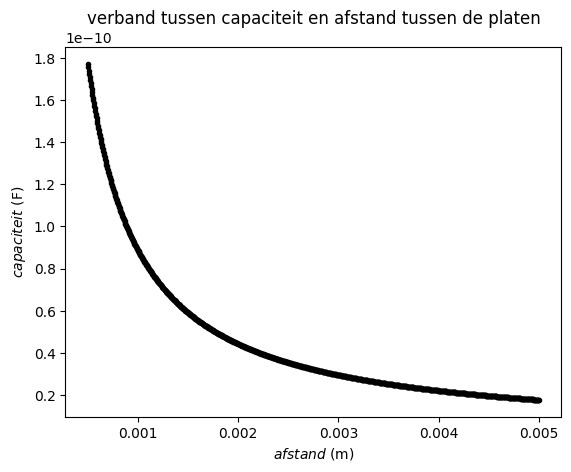

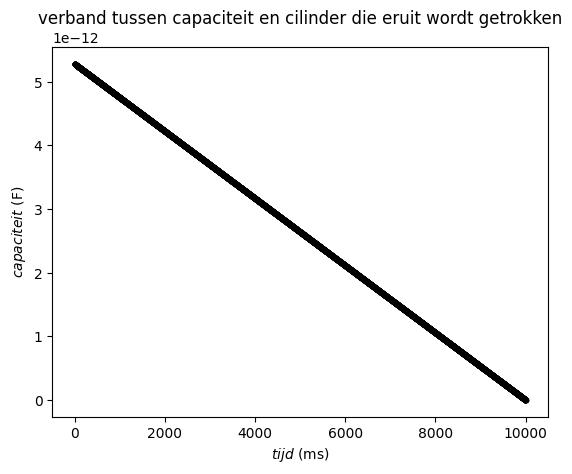

In [40]:
###
###Jouw code hier###
###
d_platen=np.linspace(0.5e-3,5e-3,1000) #lineare toename van 0.5 tot 5 mm in 1000 stappen
C_platen=vlakkeplaat(epsilon0,10e-2,10e-2,d_platen) #de capaciteit

plt.figure()
plt.title("verband tussen capaciteit en afstand tussen de platen")
plt.plot(d_platen,C_platen,"k.")
plt.xlabel('$afstand$ (m)')
plt.ylabel("$capaciteit$ (F)")
plt.show()

#5f.2
#het eruithalen van de cilinder heeft hetzelfde effect als het kleiner worden van de lengte:
t_cil=np.arange(0,10000,1)#0 tot 1000 ms
L_cil=np.linspace(10e-3,0,10000)# 10000 want in ms
C_cil=cilinder(epsilon0,L_cil,4.5e-3,5e-3)

plt.figure()
plt.title("verband tussen capaciteit en cilinder die eruit wordt getrokken")
plt.plot(t_cil,C_cil,"k.")
plt.xlabel('$tijd$ (ms)')
plt.ylabel("$capaciteit$ (F)")
plt.show()

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/Condensator_1_uF.jpg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [29]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [30]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [31]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

*Antwoord vraag 7, de laatste.*